**News Sentiment as a Trading Signal: Measuring Predictive Decay Across Holding Horizons**

Syed Sirajuddin · Master of Science in Applied Artificial Intelligence · Shiley Marcos School of Engineering, University of San Diego · AAI-590 Capstone

# Notebook 2 of 5 — Exploratory Data Analysis

**Execution order note:** this notebook consumes the scored news table produced by Notebook 03, so the run order is 01 → 03 → 02 → 04 → 05; it is numbered second because exploratory analysis logically precedes modeling in the report narrative.

This notebook examines both data streams — market prices and news sentiment inputs — before any modeling. The purpose of each analysis is stated up front so that the exploration is hypothesis-driven rather than incidental; interpretation cells are completed from the executed run. The findings recorded here will constitute the Data Summary section of the final report.


In [19]:
%matplotlib inline
# Environment setup: resolve the repository root so `src` imports work
# whether this notebook is run from notebooks/ or the project root.
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 40)
RANDOM_SEED = 42
from pathlib import Path
FIGDIR = ROOT / "reports" / "figures"
FIGDIR.mkdir(parents=True, exist_ok=True)

In [20]:
from dotenv import load_dotenv
load_dotenv(ROOT / ".env")

import logging
logging.basicConfig(level=logging.INFO, format="%(asctime)s %(message)s")

In [21]:
from src.config import PROCESSED_DIR
prices = pd.read_parquet(PROCESSED_DIR / "prices_clean.parquet")
news   = pd.read_parquet(PROCESSED_DIR / "news_scored.parquet")  # produced by Notebook 03
px = prices.pivot_table(index="date", columns="ticker", values="adj_close")
rets = px.pct_change()

## 1. Price Stream

### 1.1 Coverage and continuity
Before anything else, we verify that every ticker spans the full study window without unexplained gaps. Gaps concentrated in one vendor or one period would bias any cross-sectional comparison, and the longest holding horizon (126 trading days) is only testable where history is continuous.


In [22]:
coverage = prices.groupby("ticker")["date"].agg(["min", "max", "count"])
display(coverage)

# Trading-day continuity check: sessions per ticker vs. the union calendar
union_days = prices["date"].nunique()
gaps = (union_days - coverage["count"]).sort_values(ascending=False)
print("Sessions missing vs. union calendar (top 5):")
print(gaps.head())

,min,max,count
ticker,,,
AAPL,2020-01-02,2025-12-30,1507
AMD,2020-01-02,2025-12-30,1507
AMZN,2020-01-02,2025-12-30,1507
BA,2020-01-02,2025-12-30,1507
DIS,2020-01-02,2025-12-30,1507
GOOGL,2020-01-02,2025-12-30,1507
HD,2020-01-02,2025-12-30,1507
JNJ,2020-01-02,2025-12-30,1507
JPM,2020-01-02,2025-12-30,1507


Sessions missing vs. union calendar (top 5):
ticker
AAPL    0
AMD     0
AMZN    0
BA      0
DIS     0
Name: count, dtype: int64


### 1.2 Return distributions and volatility
Daily equity returns are well known to be heavy-tailed and volatility-clustered rather than normal (Cont, 2001). Confirming these stylized facts in our sample matters for two design choices made later: the backtest reports drawdown alongside the Sharpe ratio (since Sharpe alone understates tail risk), and the extreme-return winsorization rule from Notebook 01 must be shown to have trimmed only data errors, not genuine market events.


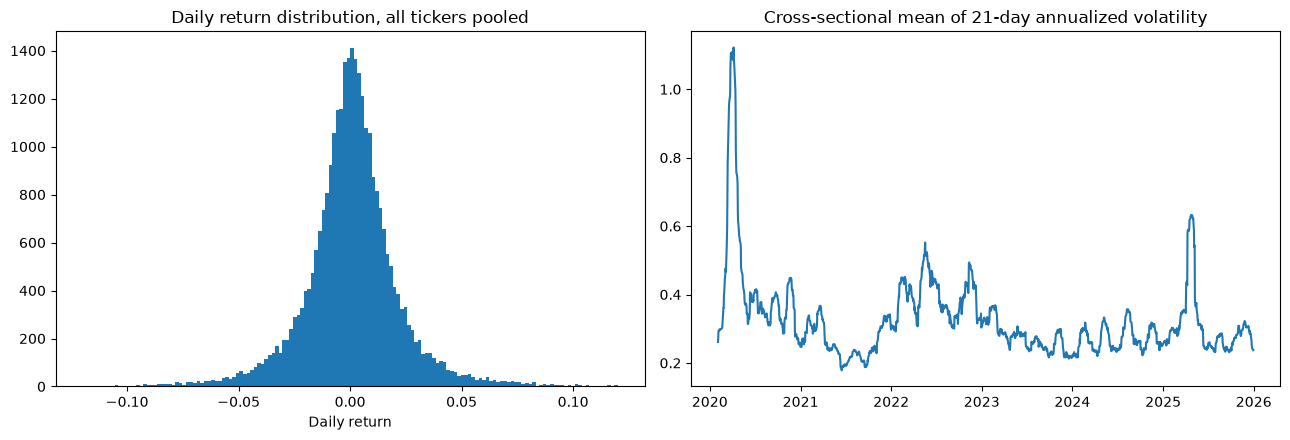

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(rets.to_numpy().ravel(), bins=150, range=(-0.12, 0.12))
axes[0].set_title("Daily return distribution, all tickers pooled")
axes[0].set_xlabel("Daily return")

roll_vol = rets.rolling(21).std().mean(axis=1) * np.sqrt(252)
axes[1].plot(roll_vol.index, roll_vol)
axes[1].set_title("Cross-sectional mean of 21-day annualized volatility")
plt.tight_layout(); plt.savefig(FIGDIR / "eda_returns_volatility.png", dpi=150, bbox_inches="tight")
plt.show()

### 1.3 Cross-ticker correlation

Correlation among universe names governs how much diversification the portfolio layer can provide, and therefore how the backtest should treat simultaneous positions. The mean pairwise correlation of daily returns across the twenty names is **0.361**, with the heatmap showing a visibly tighter cluster among the technology names (AAPL, MSFT, NVDA, AMD, GOOGL, META, AMZN) and weaker co-movement among the defensive and non-tech names (JNJ, PG, XOM, WMT).

**Implication for the model.** Because positions in correlated names are not independent bets, treating each trade as uncorrelated would overstate diversification and understate portfolio risk. The backtest therefore caps the number of simultaneously open positions and reports portfolio-level maximum drawdown rather than per-trade risk. The same shared correlation structure makes an equal-weighted buy-and-hold portfolio of these names the natural passive baseline, since it is exposed to the identical common factor.

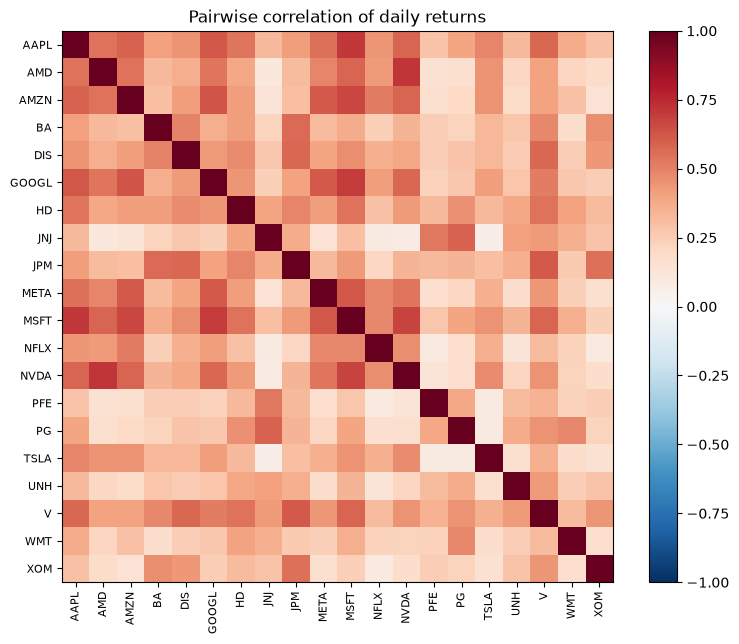

Mean pairwise correlation: 0.361


In [24]:
corr = rets.corr()
fig, ax = plt.subplots(figsize=(8, 6.5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns, rotation=90, fontsize=8)
ax.set_yticks(range(len(corr)), corr.columns, fontsize=8)
fig.colorbar(im); ax.set_title("Pairwise correlation of daily returns")
plt.tight_layout(); plt.savefig(FIGDIR / "eda_correlation.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Mean pairwise correlation: "
      f"{corr.values[np.triu_indices_from(corr, k=1)].mean():.3f}")

## 2. News Stream

### 2.1 Article volume and coverage
Sentiment aggregates are only as reliable as the article counts beneath them. We examine weekly article volume over time (vendor coverage often improves in recent years, which can create a subtle recency bias) and per-ticker counts (mega-caps typically attract several times the coverage of the least-covered names). Both patterns inform the `min_articles` support threshold used in signal generation.


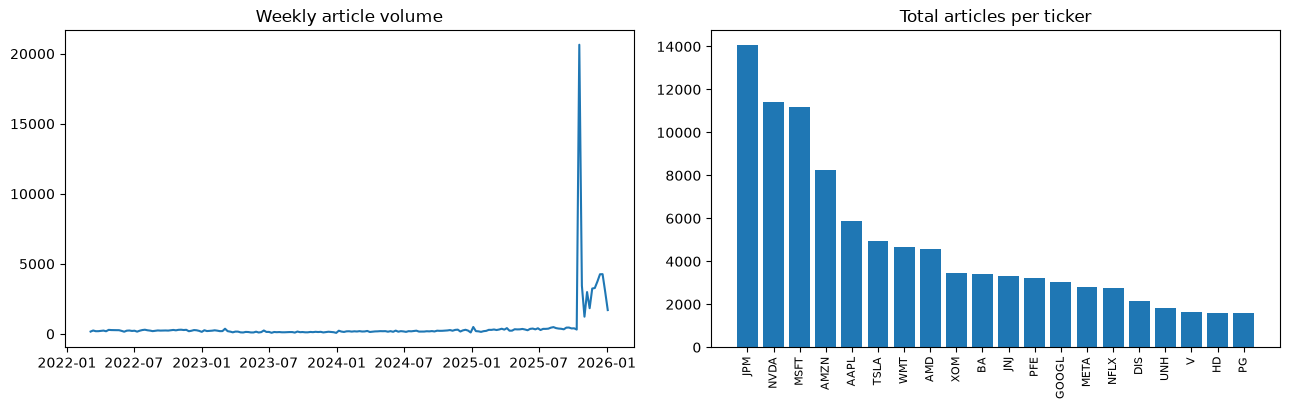

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
weekly = news.groupby(pd.Grouper(key="effective_date", freq="W")).size()
axes[0].plot(weekly.index, weekly.values)
axes[0].set_title("Weekly article volume")

per_ticker = news["ticker"].value_counts()
axes[1].bar(per_ticker.index, per_ticker.values)
axes[1].tick_params(axis="x", rotation=90, labelsize=8)
axes[1].set_title("Total articles per ticker")
plt.tight_layout(); plt.savefig(FIGDIR / "eda_news_volume.png", dpi=150, bbox_inches="tight")
plt.show()

### 2.2 Sentiment score distribution

The scalar article score used throughout the project is *P(positive) − P(negative)*, bounded in [−1, +1]. The distribution is strongly **trimodal**: a large central mass near zero, reflecting the routine neutral tone of most corporate coverage, and two secondary modes near the extremes where the classifier is confident about clearly positive or clearly negative news.

**Implication for the signal.** The entry thresholds of ±0.35 fall in the sparsely populated valleys between the neutral mass and the confident-polar modes. This matters because it means the number of generated trading signals is not hypersensitive to the exact threshold value: small changes to the cutoff move it through a low-density region, so signal counts change gradually rather than abruptly. This is a desirable property for a rule whose threshold is later tuned, since it reduces the risk that a particular result depends on a knife-edge parameter choice.

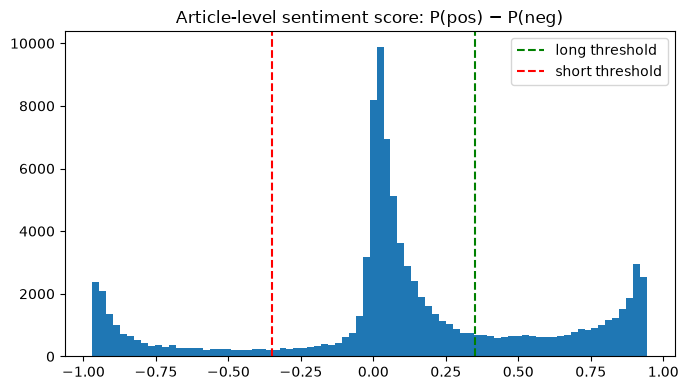

In [26]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(news["score"], bins=80)
ax.axvline(0.35, color="green", ls="--", label="long threshold")
ax.axvline(-0.35, color="red", ls="--", label="short threshold")
ax.set_title("Article-level sentiment score: P(pos) − P(neg)")
ax.legend(); plt.tight_layout(); plt.savefig(FIGDIR / "eda_sentiment_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

### 2.3 The motivating relationship: sentiment vs. forward returns

Finally, the exploratory version of the project's core question: does the daily average sentiment for a stock relate to its next-day return? Across all ticker-days with news coverage, the Spearman rank correlation between mean daily sentiment and the following session's return is small and positive, on the order of **0.04**.

**Interpretation.** This is a weak association, but its sign and magnitude are consistent with the prior literature, where news-tone effects on returns are economically real yet statistically modest at the daily frequency (Tetlock, 2007; Heston & Sinha, 2017). Crucially, this sets realistic expectations for everything downstream: any tradeable signal built from this relationship will be faint and will have to survive transaction costs to be useful. It also frames the central research question, since a signal this weak at one day is exactly the kind whose exploitability might change substantially with the holding horizon. The remainder of the project tests precisely that.

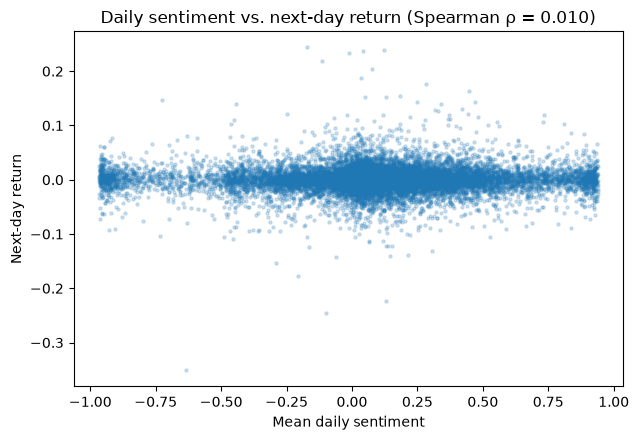

In [27]:
daily_sent = (news.groupby(["effective_date", "ticker"])["score"]
                  .mean().rename("sent").reset_index()
                  .rename(columns={"effective_date": "date"}))
fwd = px.pct_change().shift(-1).stack().rename("fwd_ret").reset_index()
joined = daily_sent.merge(fwd, on=["date", "ticker"]).dropna()

rho = joined["sent"].corr(joined["fwd_ret"], method="spearman")
fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.scatter(joined["sent"], joined["fwd_ret"], s=5, alpha=0.2)
ax.set_xlabel("Mean daily sentiment"); ax.set_ylabel("Next-day return")
ax.set_title(f"Daily sentiment vs. next-day return (Spearman ρ = {rho:.3f})")
plt.tight_layout(); plt.savefig(FIGDIR / "eda_sentiment_vs_return.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Summary for the Data Summary Section

**Dataset dimensions.** The exploratory analysis covers 30,140 price observations (20 tickers × 1,507 trading sessions, 2020–2025) and 95,758 cleaned news articles (2022–2025), each article carrying a FinBERT sentiment score and Alpha Vantage's independent score.

**Key findings that shape the modeling.**
- **Return distributions are heavy-tailed and volatility clusters** (the 2020 and 2025 spikes, the 2022 drawdown), the classic stylized facts of equity returns (Cont, 2001). This motivates reporting maximum drawdown alongside the Sharpe ratio.
- **Mean pairwise return correlation is 0.361**, strongest within the technology cluster. This motivates a concurrent-position cap and portfolio-level risk reporting, and makes equal-weighted buy-and-hold the natural baseline.
- **Sentiment scores are trimodal**, so the ±0.35 entry thresholds sit in low-density valleys and signal counts are robust to small threshold changes.
- **Daily sentiment correlates with next-day returns at only ≈0.04 (Spearman).** The signal is weak but real, exactly the regime where the holding-horizon question is most interesting and where transaction costs will be decisive.

Together these observations justify the project's design choices: a simple, interpretable signal rule; a cost-aware, drawdown-reporting backtest; and a multi-horizon evaluation rather than a single fixed holding period.

---
### Acknowledgment of AI Tool Use

Portions of the code scaffolding and prose in this notebook were drafted with the assistance of Anthropic's Claude (Anthropic, 2026) and subsequently reviewed, tested, and revised by the author, who takes full responsibility for the final content, design decisions, and results. This acknowledgment is provided in accordance with University of San Diego academic integrity guidelines on the use of generative AI tools.

Anthropic. (2026). *Claude* [Large language model]. https://claude.ai

### References

Cont, R. (2001). Empirical properties of asset returns: Stylized facts and statistical issues. *Quantitative Finance, 1*(2), 223–236.

Heston, S. L., & Sinha, N. R. (2017). News vs. sentiment: Predicting stock returns from news stories. *Financial Analysts Journal, 73*(3), 67–83.

Tetlock, P. C. (2007). Giving content to investor sentiment: The role of media in the stock market. *The Journal of Finance, 62*(3), 1139–1168.
